# Give Me Some Credit — exploration des données

**Question métier.** Un organisme de crédit veut anticiper quels emprunteurs
connaîtront un incident de paiement grave dans les deux ans, pour arbitrer ses
décisions d'octroi.

**Question de modélisation.** Classification binaire sur 150 000 dossiers,
avec une cible rare (6,7 % de défauts).

**Ce que fait ce notebook.** Il ne modélise rien. Il établit ce que valent les
données avant d'y toucher — et ce jeu contient trois pièges qui fausseraient
silencieusement n'importe quel modèle entraîné dessus sans examen préalable.

---

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("../data/raw")
FIGS = Path("../reports/figures")
FIGS.mkdir(parents=True, exist_ok=True)

# Palette : bleu pour les clients sains, orange pour les défauts.
# Les deux teintes restent distinguables en vision daltonienne.
BLEU, ORANGE, GRIS = "#2a78d6", "#eb6834", "#898781"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "text.color": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "font.size": 9,
    "grid.color": "#e1e0d9",
})

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)


def save_fig(fig, nom):
    """Enregistre la figure pour les slides et renvoie son chemin."""
    chemin = FIGS / f"{nom}.png"
    fig.savefig(chemin, dpi=150, bbox_inches="tight", facecolor="white")
    return chemin

## 1. Premier regard

On charge le fichier d'entraînement. La première colonne est un index anonyme
sans signification métier, on l'écarte tout de suite.

In [2]:
df = pd.read_csv(DATA / "cs-training.csv", index_col=0)

CIBLE = "SeriousDlqin2yrs"
print(f"{df.shape[0]:,} lignes x {df.shape[1]} colonnes".replace(",", " "))
df.head()

150 000 lignes x 11 colonnes


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Toutes les variables sont numériques : pas d'encodage catégoriel à prévoir.
apercu = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "manquants": df.isna().sum(),
    "% manquants": (df.isna().mean() * 100).round(1),
    "valeurs uniques": df.nunique(),
})
apercu

,type,manquants,% manquants,valeurs uniques
SeriousDlqin2yrs,int64,0,0.0,2
RevolvingUtilizationOfUnsecuredLines,float64,0,0.0,125728
age,int64,0,0.0,86
NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.0,16
DebtRatio,float64,0,0.0,114194
MonthlyIncome,float64,29731,19.8,13594
NumberOfOpenCreditLinesAndLoans,int64,0,0.0,58
NumberOfTimes90DaysLate,int64,0,0.0,19
NumberRealEstateLoansOrLines,int64,0,0.0,28
NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.0,13


Onze colonnes, toutes numériques, aucune variable texte ou catégorielle. Deux
colonnes seulement présentent des valeurs manquantes — on y revient en
section 3, car leur absence n'est pas anodine.

Ce tableau ne dit rien de la *qualité* des valeurs présentes. C'est justement
là que se cachent les pièges.

## 2. La cible, et le piège de l'accuracy

Première chose à regarder sur un problème de classification : l'équilibre des
classes. Il détermine le choix de la métrique, et donc tout le reste.

In [4]:
repartition = df[CIBLE].value_counts().sort_index()
taux = df[CIBLE].mean()

print(f"Clients sains  : {repartition[0]:>7,}".replace(",", " "))
print(f"Défauts        : {repartition[1]:>7,}".replace(",", " "))
print(f"Taux de défaut : {taux:.2%}")
print()
print(f"Un modèle qui prédirait 'jamais de défaut' pour tout le monde")
print(f"obtiendrait une accuracy de {1 - taux:.2%} tout en étant sans valeur.")

Clients sains  : 139 974
Défauts        :  10 026
Taux de défaut : 6.68%

Un modèle qui prédirait 'jamais de défaut' pour tout le monde
obtiendrait une accuracy de 93.32% tout en étant sans valeur.


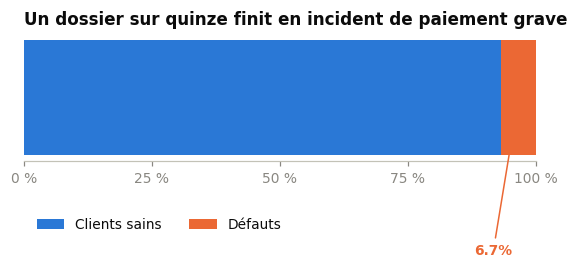

In [5]:
fig, ax = plt.subplots(figsize=(6, 1.5))
ax.barh([0], [1 - taux], color=BLEU, height=0.55, label="Clients sains")
ax.barh([0], [taux], left=[1 - taux], color=ORANGE, height=0.55, label="Défauts")
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(["0 %", "25 %", "50 %", "75 %", "100 %"])
ax.spines["left"].set_visible(False)
ax.set_title("Un dossier sur quinze finit en incident de paiement grave")
ax.annotate(f"{taux:.1%}", xy=(1 - taux / 2, 0), xytext=(0.88, -0.75),
            color=ORANGE, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1))
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.35), ncol=2, frameon=False)
save_fig(fig, "01_desequilibre_cible")
plt.show()

**Conséquence pratique.** L'accuracy est inutilisable ici : 93,3 % sans rien
faire. On pilotera le modèle à l'**AUC**, qui mesure la qualité du classement
des clients par risque et vaut 0,5 pour un modèle constant.

Pour la restitution métier, l'AUC ne suffira pas non plus — on y ajoutera la
**précision** (parmi les dossiers refusés, combien auraient vraiment fait
défaut), qui est la question que se pose réellement un directeur des risques.

## 3. Piège n°1 — une absence qui porte de l'information

Deux colonnes ont des valeurs manquantes. Le réflexe paresseux consiste à
imputer par la médiane et passer à la suite. Vérifions d'abord si l'absence
elle-même est liée au défaut.

In [6]:
manquants = df.columns[df.isna().any()].tolist()

lignes = []
for col in manquants:
    absent = df[col].isna()
    lignes.append({
        "variable": col,
        "% manquant": f"{absent.mean():.1%}",
        "taux de défaut si absent": f"{df.loc[absent, CIBLE].mean():.2%}",
        "taux de défaut si présent": f"{df.loc[~absent, CIBLE].mean():.2%}",
    })
pd.DataFrame(lignes)

,variable,% manquant,taux de défaut si absent,taux de défaut si présent
0,MonthlyIncome,19.8%,5.61%,6.95%
1,NumberOfDependents,2.6%,4.56%,6.74%


Le revenu manque pour un dossier sur cinq, et ces dossiers font **moins**
défaut que les autres (5,6 % contre 7,0 %). L'écart est faible mais porté par
près de 30 000 lignes, donc il est réel et non un artefact d'échantillonnage.

**Décision.** Imputer, mais conserver la trace de l'absence dans une variable
indicatrice `MonthlyIncome_manquant`. Une imputation seule effacerait ce signal.

## 4. Piège n°2 — des codes de saisie déguisés en compteurs

Les trois colonnes qui comptent les incidents de paiement passés ont l'air
inoffensives. Regardons leurs valeurs extrêmes.

In [7]:
COMPTEURS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for col in COMPTEURS:
    vc = df[col].value_counts().sort_index()
    hautes = vc[vc.index >= 90]
    print(f"{col}")
    print(f"   valeurs 0 à 20 : {vc[vc.index < 90].index.min()} à {vc[vc.index < 90].index.max()}"
          f"   |   valeurs >= 90 : {dict(hautes)}")

NumberOfTime30-59DaysPastDueNotWorse
   valeurs 0 à 20 : 0 à 13   |   valeurs >= 90 : {96: np.int64(5), 98: np.int64(264)}
NumberOfTime60-89DaysPastDueNotWorse
   valeurs 0 à 20 : 0 à 11   |   valeurs >= 90 : {96: np.int64(5), 98: np.int64(264)}
NumberOfTimes90DaysLate
   valeurs 0 à 20 : 0 à 17   |   valeurs >= 90 : {96: np.int64(5), 98: np.int64(264)}


Les compteurs plafonnent naturellement vers 20, puis plus rien... jusqu'à 96 et
98. Ce ne sont pas des retards de paiement : ce sont des **codes de saisie**
(donnée non disponible, dossier non exploitable). Deux vérifications le
confirment.

In [8]:
sentinelle = df[COMPTEURS[0]] >= 90

# 1. Les trois colonnes portent-elles le code sur exactement les mêmes lignes ?
memes_lignes = all((df[c] >= 90).equals(sentinelle) for c in COMPTEURS)
print(f"Code présent sur les mêmes lignes dans les 3 colonnes : {memes_lignes}")
print(f"Nombre de lignes concernées : {sentinelle.sum()}")
print()

# 2. Ces lignes se comportent-elles différemment face au défaut ?
print(f"Taux de défaut sur ces lignes      : {df.loc[sentinelle, CIBLE].mean():.1%}")
print(f"Taux de défaut sur le reste        : {df.loc[~sentinelle, CIBLE].mean():.1%}")
print(f"Soit un risque {df.loc[sentinelle, CIBLE].mean() / df.loc[~sentinelle, CIBLE].mean():.1f} fois plus élevé.")

Code présent sur les mêmes lignes dans les 3 colonnes : True
Nombre de lignes concernées : 269

Taux de défaut sur ces lignes      : 54.6%
Taux de défaut sur le reste        : 6.6%
Soit un risque 8.3 fois plus élevé.


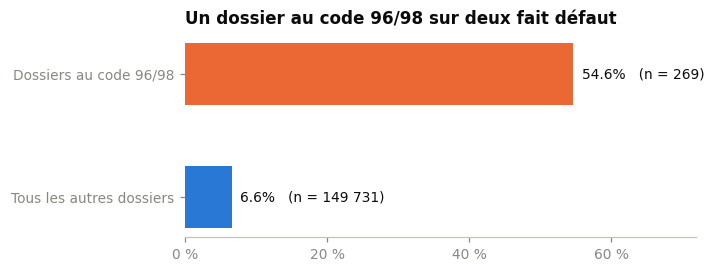

In [9]:
fig, ax = plt.subplots(figsize=(6, 2.4))
groupes = ["Dossiers au code 96/98", "Tous les autres dossiers"]
valeurs = [df.loc[sentinelle, CIBLE].mean(), df.loc[~sentinelle, CIBLE].mean()]
effectifs = [sentinelle.sum(), (~sentinelle).sum()]

barres = ax.barh(groupes, valeurs, color=[ORANGE, BLEU], height=0.5)
for barre, val, n in zip(barres, valeurs, effectifs):
    ax.text(val + 0.012, barre.get_y() + barre.get_height() / 2,
            f"{val:.1%}   (n = {n:,})".replace(",", " "),
            va="center", fontsize=9, color="#0b0b0b")
ax.set_xlim(0, 0.72)
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_xticklabels(["0 %", "20 %", "40 %", "60 %"])
ax.invert_yaxis()
ax.spines["left"].set_visible(False)
ax.set_title("Un dossier au code 96/98 sur deux fait défaut")
save_fig(fig, "02_codes_sentinelles")
plt.show()

**Plus d'un dossier sur deux y fait défaut**, contre 6,6 % ailleurs : c'est le
signal le plus fort de tout le jeu de données.

**Décision.** Surtout ne pas supprimer ces 269 lignes. Remplacer la valeur
numérique par `NaN` — sinon le modèle lit « 98 retards de paiement » et la
variable est ruinée — et créer une indicatrice `code_saisie` qui préserve
l'information.

## 5. Piège n°3 — deux unités dans une même colonne

`DebtRatio` devrait être un ratio, donc tourner autour de 1. Sa médiane est
cohérente, mais pas sa queue de distribution.

In [10]:
df["DebtRatio"].describe(percentiles=[0.5, 0.75, 0.95, 0.99]).round(2)

count    150000.00
mean        353.01
std        2037.82
min           0.00
50%           0.37
75%           0.87
95%        2449.00
99%        4979.04
max      329664.00
Name: DebtRatio, dtype: float64

Médiane à 0,37, mais 95e percentile à 2 449 et maximum à 329 664. Quelque chose
ne tient pas. Hypothèse : quand le revenu est inconnu ou nul, la division est
impossible et le champ contient le **montant brut de dette**. Testons-la.

In [11]:
eleve = df["DebtRatio"] > 10

diagnostic = pd.DataFrame({
    "DebtRatio > 10": [
        f"{eleve.sum():,}".replace(",", " "),
        f"{df.loc[eleve, 'MonthlyIncome'].isna().mean():.1%}",
        f"{(df.loc[eleve, 'MonthlyIncome'] == 0).mean():.1%}",
    ],
    "DebtRatio <= 10": [
        f"{(~eleve).sum():,}".replace(",", " "),
        f"{df.loc[~eleve, 'MonthlyIncome'].isna().mean():.1%}",
        f"{(df.loc[~eleve, 'MonthlyIncome'] == 0).mean():.1%}",
    ],
}, index=["effectif", "revenu manquant", "revenu nul"])
diagnostic

,DebtRatio > 10,DebtRatio <= 10
effectif,28 877,121 123
revenu manquant,92.7%,2.4%
revenu nul,5.0%,0.2%


Hypothèse confirmée : **92,7 %** des lignes à `DebtRatio` élevé ont un revenu
manquant, contre 2,4 % ailleurs. En ajoutant les revenus nuls, on explique la
quasi-totalité des cas. La colonne mélange donc deux unités incompatibles, un
ratio et un montant en dollars.

**Décision.** Traiter séparément les lignes où le ratio n'a pas pu être
calculé, plutôt que de laisser le modèle comparer des dollars à des ratios.

## 6. Anomalies résiduelles

Deux invraisemblances plus classiques, à traiter mais sans grande portée.

In [12]:
print(f"Âge minimum observé : {df['age'].min()}  (nombre de dossiers < 18 ans : {(df['age'] < 18).sum()})")

util = df["RevolvingUtilizationOfUnsecuredLines"]
print(f"Taux d'utilisation du crédit > 1   : {(util > 1).sum():,}".replace(",", " "))
print(f"Taux d'utilisation du crédit > 10  : {(util > 10).sum():,}".replace(",", " "))
print(f"Maximum observé                    : {util.max():,.0f}".replace(",", " "))

Âge minimum observé : 0  (nombre de dossiers < 18 ans : 1)
Taux d'utilisation du crédit > 1   : 3 321
Taux d'utilisation du crédit > 10  : 241
Maximum observé                    : 50 708


Un dossier affiche un âge de 0 : erreur de saisie manifeste, à traiter comme
une valeur manquante.

Le taux d'utilisation dépasse 1 pour 3 321 dossiers. Au-delà de 1, cela reste
plausible jusqu'à un certain point (dépassement de plafond, frais et intérêts
capitalisés), mais un taux de 50 708 ne l'est pas. On écrêtera plutôt que de
supprimer, pour ne pas perdre de lignes.

## 7. Quelles variables séparent réellement les deux populations ?

Pour chaque variable, on découpe la population en déciles et on regarde le taux
de défaut de chaque tranche. Une variable utile produit une pente marquée ; une
variable plate n'apporte rien.

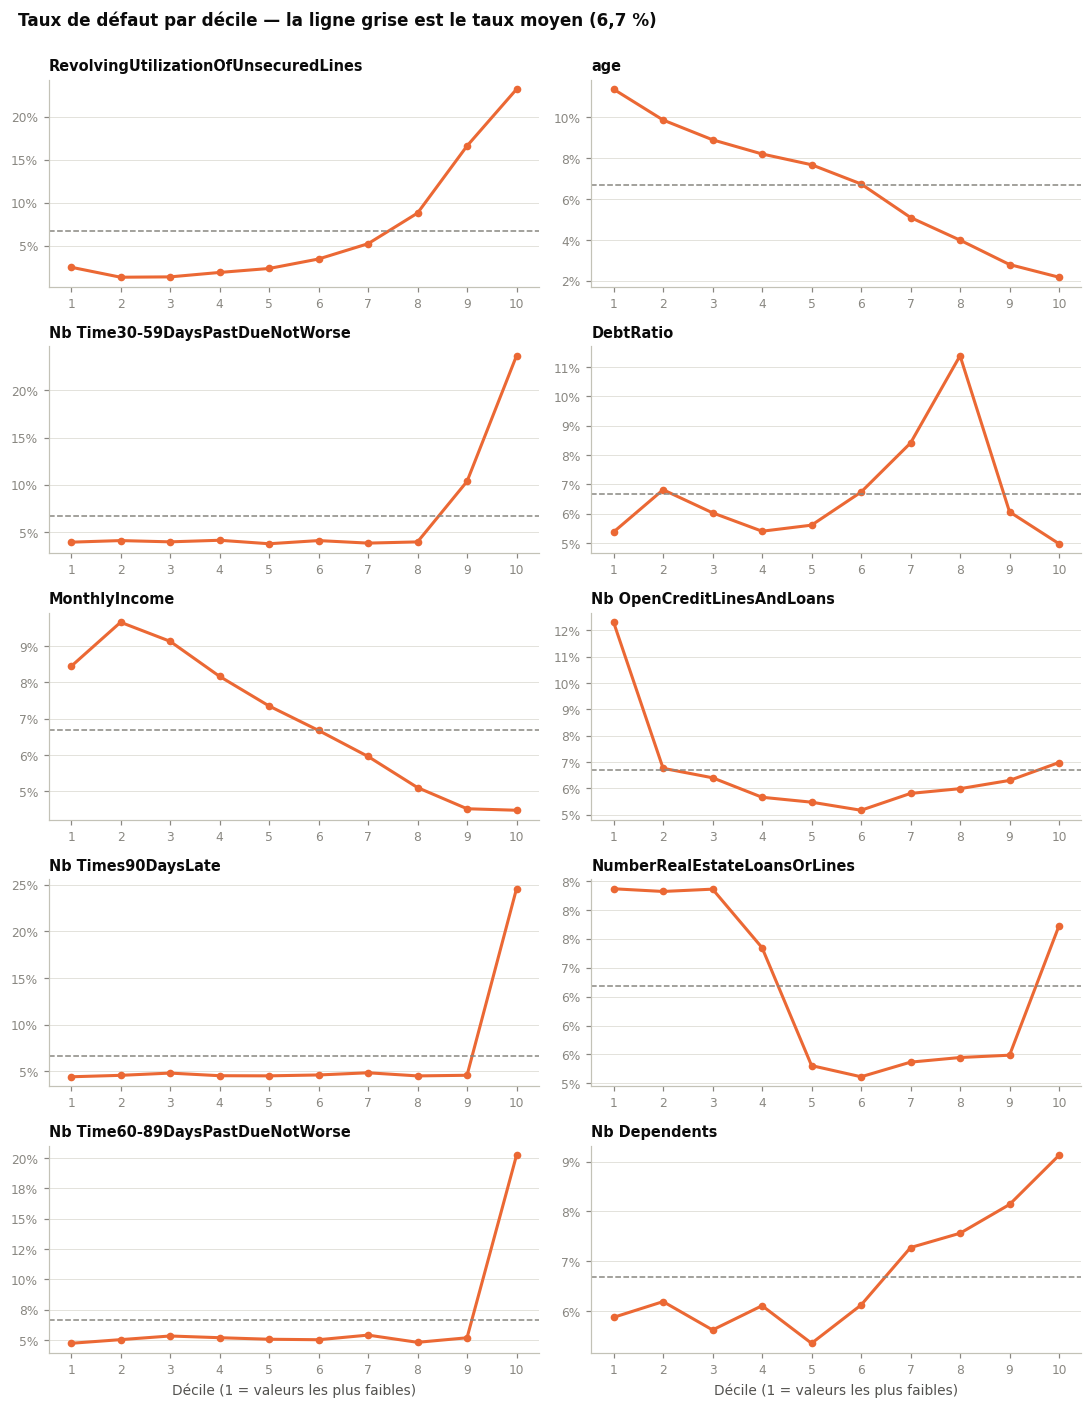

In [13]:
propre = df.copy()
propre[COMPTEURS] = propre[COMPTEURS].mask(propre[COMPTEURS] >= 90)
propre.loc[propre["age"] < 18, "age"] = np.nan

variables = [c for c in propre.columns if c != CIBLE]

fig, axes = plt.subplots(5, 2, figsize=(10, 13), sharey=False)
for ax, col in zip(axes.ravel(), variables):
    tranches = pd.qcut(propre[col].rank(method="first"), 10, labels=False, duplicates="drop")
    profil = propre.groupby(tranches, observed=True)[CIBLE].mean()
    ax.plot(profil.index + 1, profil.values, marker="o", markersize=4,
            color=ORANGE, linewidth=2)
    ax.axhline(taux, color=GRIS, linestyle="--", linewidth=1)
    ax.set_title(col.replace("NumberOf", "Nb "), fontsize=9.5)
    ax.set_xticks(range(1, 11))
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.grid(axis="y", linewidth=0.6)

axes[-1, 0].set_xlabel("Décile (1 = valeurs les plus faibles)")
axes[-1, 1].set_xlabel("Décile (1 = valeurs les plus faibles)")
fig.suptitle("Taux de défaut par décile — la ligne grise est le taux moyen (6,7 %)",
             x=0.02, ha="left", fontsize=11, fontweight="semibold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
save_fig(fig, "03_taux_defaut_par_decile")
plt.show()

Quatre enseignements, dont deux qui ne se voient qu'en lisant la forme des
courbes plutôt que leur amplitude :

- Le **taux d'utilisation du crédit** est le signal le plus fort et le plus
  régulier : de 2,5 % de défaut dans le premier décile à 23,2 % dans le
  dernier. Plus un client sature ses lignes de crédit, plus il fait défaut, et
  la progression est continue.
- Les **compteurs d'incidents passés** sont tout aussi discriminants (jusqu'à
  24,6 % dans le dernier décile), mais leur courbe est plate sur huit déciles
  puis explose. Ce n'est pas un effet de seuil : 84 % à 94 % des clients n'ont
  **aucun** incident, donc les huit premiers déciles contiennent tous la même
  valeur, zéro. Le découpage en déciles est inadapté à une variable aussi
  concentrée — c'est la lecture qui est trompeuse, pas la variable.
- L'**âge** décroît de façon monotone, de 11,4 % chez les plus jeunes à 2,2 %
  chez les plus âgés.
- `DebtRatio` monte jusqu'à 11,4 % au huitième décile puis **retombe** à 5 %.
  Cette rupture n'a rien d'un comportement de risque : c'est le piège de la
  section 5 qui réapparaît. Vérifions-le.

In [14]:
tranches = pd.qcut(df["DebtRatio"].rank(method="first"), 10, labels=False)
profil_ratio = df.groupby(tranches).apply(
    lambda d: pd.Series({
        "taux de défaut": d[CIBLE].mean(),
        "revenu manquant": d["MonthlyIncome"].isna().mean(),
        "DebtRatio médian": d["DebtRatio"].median(),
    }),
    include_groups=False,
)
profil_ratio.index = [f"décile {i + 1}" for i in profil_ratio.index]
profil_ratio.style.format({
    "taux de défaut": "{:.1%}", "revenu manquant": "{:.0%}", "DebtRatio médian": "{:,.2f}",
})

,taux de défaut,revenu manquant,DebtRatio médian
décile 1,5.4%,11%,0.00
décile 2,6.8%,0%,0.09
décile 3,6.0%,0%,0.18
décile 4,5.4%,0%,0.25
décile 5,5.6%,0%,0.32
décile 6,6.7%,0%,0.41
décile 7,8.4%,0%,0.54
décile 8,11.4%,4%,0.87
décile 9,6.1%,89%,269.50
décile 10,5.0%,94%,"2,449.00"


Les deux derniers déciles sont à **89 % et 94 % de revenus manquants**, avec un
`DebtRatio` médian de 269 et 2 449 — ce ne sont plus des ratios mais des
montants en dollars. Leur faible taux de défaut ne décrit donc pas un profil
de client peu risqué : il décrit un sous-population définie par une donnée
absente, mélangée au reste par accident d'unité.

C'est exactement le genre de relation qu'un modèle apprendrait sans broncher,
et qui s'effondrerait en production dès que la collecte du revenu s'améliore.

## 8. Redondance entre variables

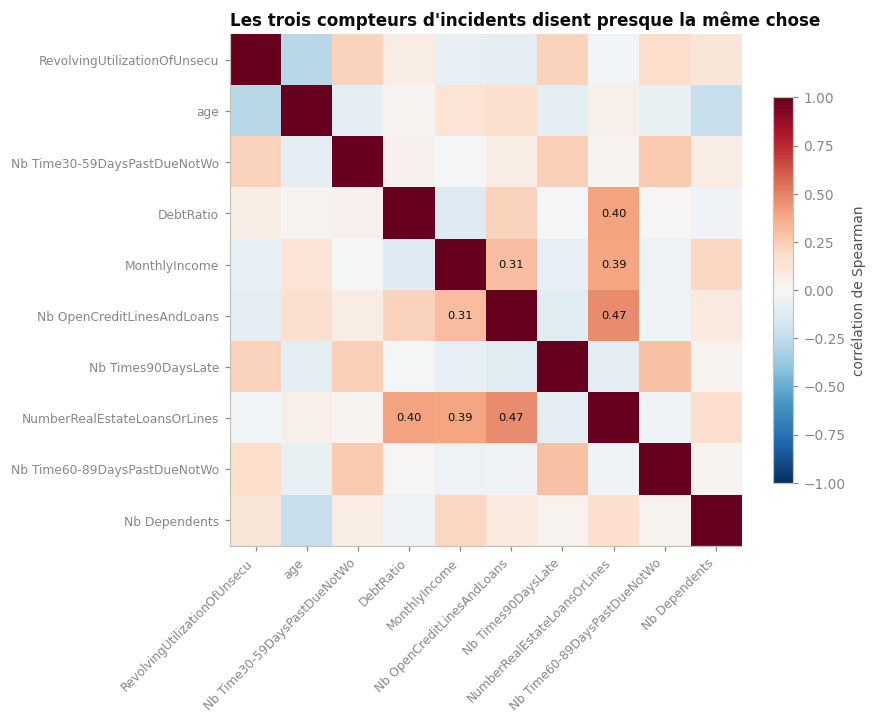

In [15]:
correl = propre[variables].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(correl, cmap="RdBu_r", vmin=-1, vmax=1)
etiquettes = [c.replace("NumberOf", "Nb ")[:28] for c in variables]
ax.set_xticks(range(len(variables)), etiquettes, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(variables)), etiquettes, fontsize=8)
for i in range(len(variables)):
    for j in range(len(variables)):
        v = correl.iloc[i, j]
        if i != j and abs(v) > 0.3:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(v) > 0.6 else "#0b0b0b")
fig.colorbar(im, ax=ax, shrink=0.7, label="corrélation de Spearman")
ax.set_title("Les trois compteurs d'incidents disent presque la même chose")
save_fig(fig, "04_correlations")
plt.show()

Les trois compteurs d'incidents sont fortement corrélés entre eux, ce qui est
attendu : un client qui accumule des retards à 30 jours en accumule aussi à 90.
Sans conséquence pour un modèle à base d'arbres, mais à surveiller pour une
régression logistique, où la colinéarité rend les coefficients instables et
ininterprétables.

## 9. Synthèse — ce qu'il faut faire avant de modéliser

| Constat | Décision |
|---|---|
| Cible à 6,7 % | Piloter à l'AUC, jamais à l'accuracy ; ajouter la précision pour le métier |
| Codes 96/98 sur 269 lignes (54,6 % de défaut) | Passer en `NaN` **et** créer une indicatrice — ne jamais supprimer |
| Revenu manquant sur 19,8 % des lignes, lié au défaut | Imputer **et** créer une indicatrice d'absence |
| `DebtRatio` mélange ratio et montant brut | Isoler les lignes où le ratio n'a pas pu être calculé |
| Âge à 0, utilisation du crédit jusqu'à 50 708 | Passer en `NaN` pour l'âge, écrêter l'utilisation |
| Compteurs d'incidents fortement corrélés | Sans effet sur les arbres, à surveiller en régression logistique |

**Étape suivante** — `02_preparation.ipynb` : appliquer ces décisions dans un
pipeline scikit-learn reproductible, et vérifier qu'aucune d'elles ne dégrade
l'AUC obtenue par un modèle de référence.

Point de vigilance pour la suite : toutes ces transformations devront être
apprises **sur le jeu d'entraînement uniquement** puis appliquées à la
validation. Calculer une médiane d'imputation sur l'ensemble des données est
une fuite classique, qui gonfle le score sans améliorer le modèle.